<a href="https://colab.research.google.com/github/muiddd/5thSemester_PCVK/blob/main/latihan_integrasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt


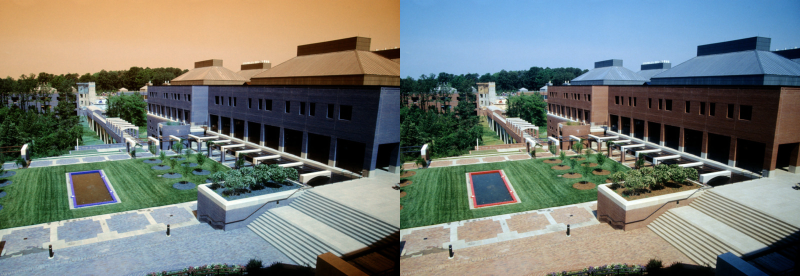

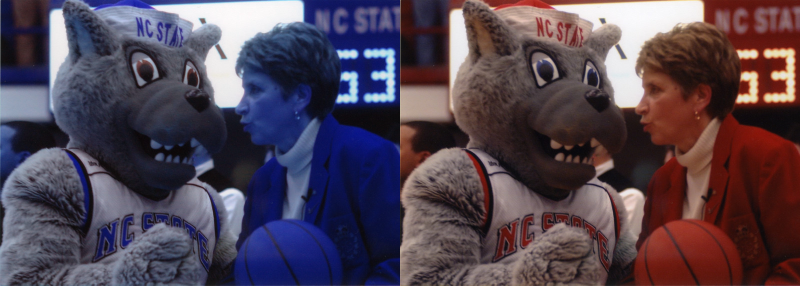

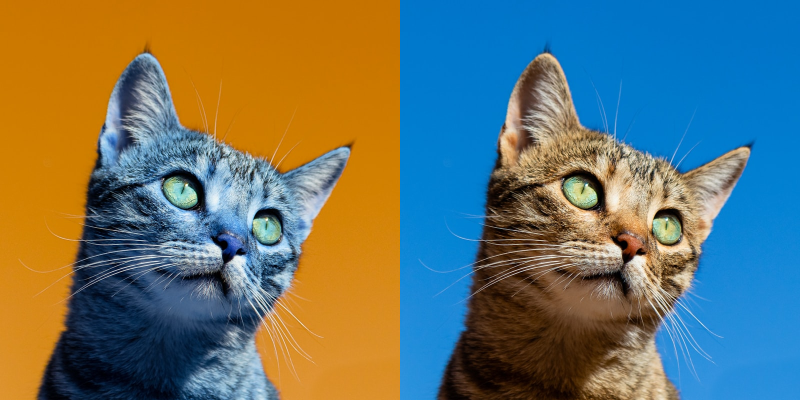

In [26]:
# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=800"]

# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                                #read image
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)       #resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)        #convert color to RGB
    final_frame = cv.hconcat((image, image_2))            #concatenate image
    cv2_imshow(final_frame)                               #show image
    print('\n')

resolusi image: tinggi x lebar =  400  x  400


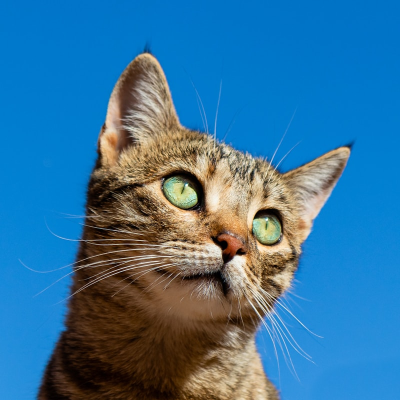

In [27]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ",tinggi," x ", lebar)
cv2_imshow(image_2)

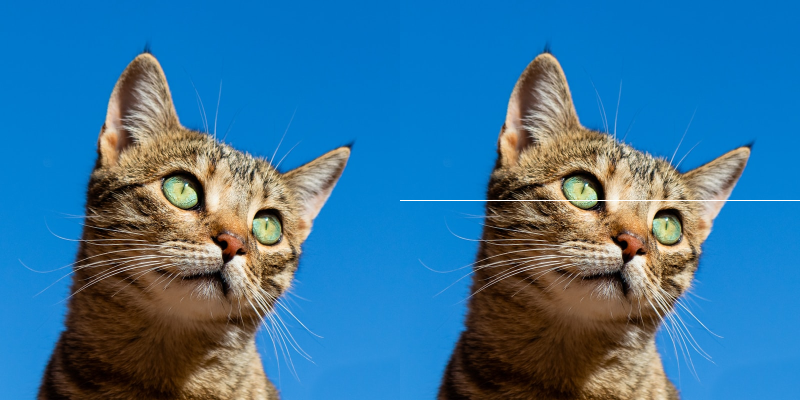

In [33]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#membuat garis horizontal ditengah image
for y in range (lebar) :
  image_3[int((tinggi)/2),y] = [255,255,255]
final_frame = cv.hconcat((image_2,image_3))
cv2_imshow(final_frame)

# **Pembahasan Pertanyaan Praktikum D2**
Mengapa menggunakan Google Colab?

1.   **Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan
menggunakan Google Colab?** Karena
Google Colab memungkinkan penggunanya untuk menulis dan mengeksekusi Python di browser tanpa memerlukan konfigurasi atau instalasi lokal. Selain itu, Colab menyediakan akses GPU secara gratis yang sangat membantu untuk eksperimen computer vision.
2.   **Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke
delapan? Apakah semua library tersebut harus digunakan dalam praktikum
sesi ini?** Tidak semua library wajib digunakan secara bersamaan, namun bergantung pada kebutuhan spesifik langkah tersebut. Berikut adalah fungsinya:
Numpy: Manipulasi array, aljabar linear, dan transformasi Fourier.  Pandas: Manipulasi dan analisis data.  CV2 (OpenCV): Pustaka khusus untuk tugas-tugas computer vision.  Skimage: Mendukung aplikasi pemrosesan citra pada Python.  Matplotlib: Menghasilkan gambar (figures) dan menyediakan toolkit antarmuka grafis.
2. **Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut :
Apa kegunaan kode program tersebut?dan apa pengaruhnya jika tidak
dilakukan?** Kode ini berfungsi untuk mengubah ukuran (resize) citra menjadi setengah ukuran aslinya (faktor skala 0.5). Jika tidak dilakukan, citra akan ditampilkan dalam ukuran aslinya yang mungkin terlalu besar.
2.   **Perhatikan potongan kode progam berikut :
Apakah kegunaan kode [255,255,255] ? Jelaskan!** Nilai tersebut merepresentasikan warna putih pada piksel citra. Pada modul, nilai ini ditugaskan pada piksel di baris tengah citra untuk menggambar garis horizontal berwarna putih.
1.   **Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun
rendah!** Resolusi citra didefinisikan sebagai jumlah piksel dalam dimensi horizontal x vertikal. Semakin tinggi resolusinya (jumlah pikselnya lebih banyak), maka semakin detail informasi yang dapat ditampilkan oleh citra tersebut.








# **Tugas Praktikum D2**




Hasil Tugas 2 (Kiri: Vertikal, Kanan: Menyilang Diagonal):


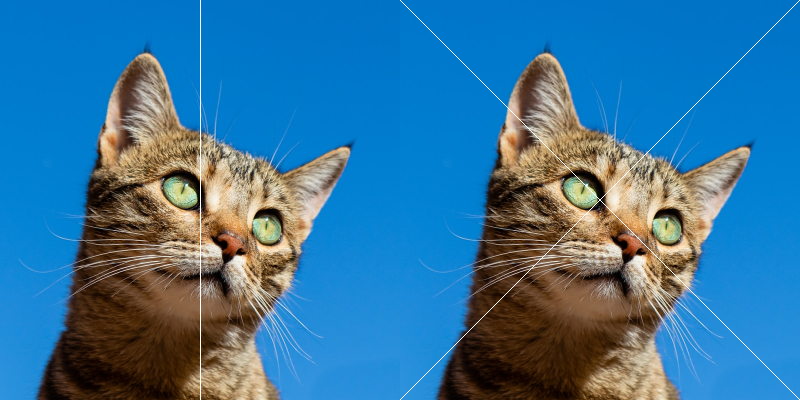


Hasil Tugas 3 (Garis Horizontal Terbatas):


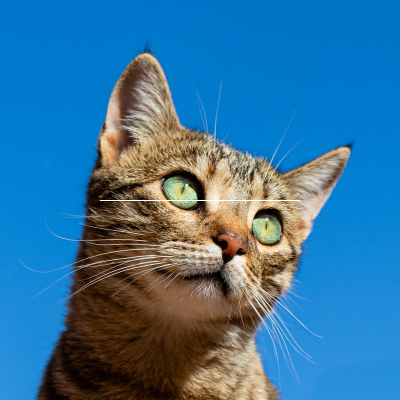


Hasil Tugas 4 (Kotak Putih):


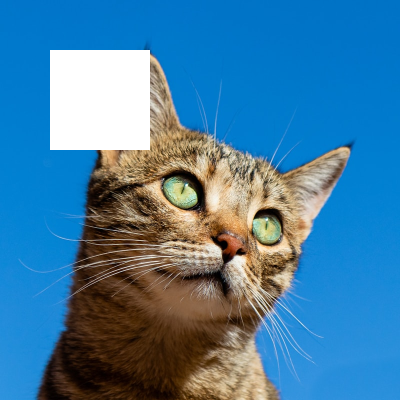

In [48]:
# Mengambil dimensi dari citra terakhir yang diproses di cell sebelumnya (image_2)
tinggi = image_2.shape[0]
lebar = image_2.shape[1]

# -------------------------------------------------------------
# TUGAS 2: Garis Vertikal dan Garis Menyilang Diagonal
# -------------------------------------------------------------
img_vertikal = image_2.copy()
img_diagonal = image_2.copy()

# 1. Gambar Pertama: Garis Vertikal (di tengah)
for x in range(tinggi):
    img_vertikal[x, int(lebar/2)] = [255, 255, 255]

# 2. Gambar Kedua: Garis Menyilang Diagonal (membentuk huruf X)
for x in range(tinggi):
    # Garis dari kiri atas ke kanan bawah
    y_kiri_ke_kanan = int(x * (lebar / tinggi))
    if y_kiri_ke_kanan < lebar:
        img_diagonal[x, y_kiri_ke_kanan] = [255, 255, 255]

    # Garis dari kanan atas ke kiri bawah
    y_kanan_ke_kiri = int((tinggi - x - 1) * (lebar / tinggi))
    if y_kanan_ke_kiri < lebar:
        img_diagonal[x, y_kanan_ke_kiri] = [255, 255, 255]

# Menggabungkan gambar vertikal dan diagonal secara horizontal agar bersebelahan
hasil_gabungan = cv.hconcat((img_vertikal, img_diagonal))

print("Hasil Tugas 2 (Kiri: Vertikal, Kanan: Menyilang Diagonal):")
cv2_imshow(hasil_gabungan)

# -------------------------------------------------------------
# TUGAS 3: Garis Horizontal Berwarna Putih dengan Panjang Tertentu
# -------------------------------------------------------------
img_tugas3 = image_2.copy()

# Garis horizontal di tengah, memanjang dari piksel ke-100 sampai ke-300
for y in range(100, 300):
    if y < lebar: # Memastikan indeks tidak melebihi lebar gambar
        img_tugas3[int(tinggi/2), y] = [255, 255, 255]

print("\nHasil Tugas 3 (Garis Horizontal Terbatas):")
cv2_imshow(img_tugas3)

# -------------------------------------------------------------
# TUGAS 4: Kotak Putih di Sembarang Tempat
# -------------------------------------------------------------
img_tugas4 = image_2.copy()

# Membuat kotak putih (menggunakan teknik slicing array NumPy)
# Misal: dari baris 50 sampai 150, dan kolom 50 sampai 150
img_tugas4[50:150, 50:150] = [255, 255, 255]

print("\nHasil Tugas 4 (Kotak Putih):")
cv2_imshow(img_tugas4)